## TRANSPORTE DE 2 ESPECIES EN EQUILIBRIO CON EL YESO  (1D) 
## Modelación de la concentración $c_2 = Ca^{2+}$
### Flujo y transporte conservativo en 1D utilizando GWF, GWT y Flopy

$$
\frac{\partial}{\partial x}( K \frac{\partial h }{\partial x})+ q_s = S_s \frac{\partial h }{\partial t} $$

$$
    \frac {\partial\left(\theta C^k\right)}{\partial t}  = \frac{\partial}{\partial x}\left(\theta D \frac{\partial C^k}{\partial x}\right)- \frac{\partial}{\partial x} (\theta v C^k) + q_s C^{k}_{s} 
$$
<!-- <img src="dominio2.png"> -->



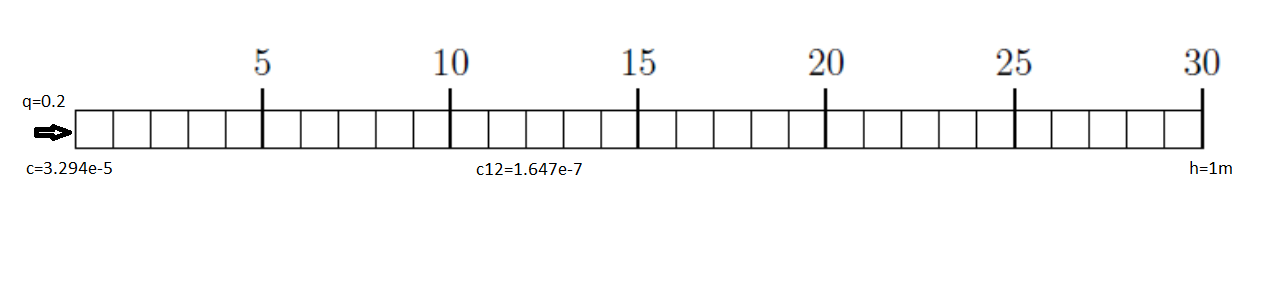

In [2]:
# insertar imagen incrustada en base64 dentro del notebook
from IPython.display import HTML
import base64
# Ruta de tu imagen
image_path = "dominio2.png"
# Leer imagen como base64
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")
# HTML para incrustar la imagen
html = f'<img src="data:image/png;base64,{image_base64}" />'
# Mostrar imagen
HTML(html)

* **Problema de flujo 1D**
* con las siguientes dimensiones del dominio: 
* LX=30m, LY=1m, LZ=1m
* considerando las siguientes condiciones de frontera:
* Flujo prescrito en la frontera izquierda CFI= 0.2 m3/d
* Carga prescrita en la frontera derecha CFD=1m  
* **Problema de transporte 1D**
* considerando las siguientes condiciones de frontera y condiciones iniciales:
* Concentración prescrita en el fluído entrante $cfi = c_2 =$ 3.294E-5 en la frontera izquierda
* Concentración inicial $c_{2_i}$=3.294E-5. en todo el dominio excepto en la celda 12, donde $c_{2_{12_i}}$=1.647E-7
* Se usa la Ley de acción de masas para obtener $cfi,ci,c12i$, 
* $c_{2_i}=K_e/c_{1_i}$=3.29382e-5/1.0000329= 3.294E-5, $c_{2_{12_i}}$=3.29382e-5/200=1.647E-7
* **Las propiedades físicas del problema son**:
* Conductividad hidráulica = 1.0 m/día
* Porosidad = 0.5
* Dispersividad longitudinal =0.2
* Factor de retardación =1.0
* Se simulan 40 días en 40 pasos de tiempo


## Se localiza dinámicamente el directorio "WMACC\src\ft1D" en la estructura de archivos del sistema y lo añade al inicio de sys.path. Esto asegura que el intérprete de Python pueda importar módulos desde este directorio.

In [5]:
import os, sys # interactuar con el sistema operativo para manejo de rutas y directorios, acceso a variables y funciones.
c_path = os.getcwd() #Obtener el directorio actual de trabajo como una cadena.
l_path = c_path.split(sep="\\") #Divide la ruta c_path en una lista, usando como separador  (\\)
i_wma = l_path.index('WMACC') #Busca y guarda el índice de la carpeta llamada 'WMACC' dentro de la lista l_path.
a_path = '\\'.join(l_path[:i_wma]) #a_path se construye uniendo elementos de l_path hasta el índice  'WMACC' inclusive
src_path = '\\WMACC\\src\\ft1D' #Cadena que define una ruta específica dentro del directorio 'WMACC' hacia un subdirectorio de código fuente
if not(src_path in sys.path[0]): #Si la ruta src_path no es el primer elemento en la lista sys.path (que Python usa para buscar módulos), se inserta esta ruta al inicio de la lista
    sys.path.insert(0, os.path.abspath(a_path + src_path)) 
#print('c_path = ',c_path) #C:\Users\NRBRT\clone\WMACC\notebooks\2_Transporte_mf6_1D
#print('l_path = ',l_path) #['C:', 'Users', 'NRBRT', 'clone', 'WMACC', 'notebooks', '2_Transporte_mf6_1D']
#print('i_wma = ',i_wma) # 4
#print('a_path = ',a_path) #C:\Users\NRBRT\clone
#print('src_path = ',src_path) #\WMACC\src\ft1D

## Importa librerías para cálculos numéricos (numpy), visualización (matplotlib), interacción con modelos MODFLOW (flopy), y módulos personalizados

In [7]:
import os, sys #Importar módulos de sistema para interactuar con el sistema operativo y manipular el entorno de Python.
import numpy as np # Importar numpy como np: para cálculos numéricos y manejo de arrays.
import matplotlib.pyplot as plt #Función para crear visualizaciones gráficas de los datos.  plt.plot(), plt.show()

import flopy #Para la modelación de flujo subterráneo con MODFLOW y otras herramientas relacionadas.
from flopy.plot.styles import styles #Para aplicar estilos predefinidos a las gráficas de los modelos.
import xmf6 #Módulo específico para funciones extendidas en modelación.
from flow_1D import build_gwf_1D #Se importa build_gwf_1D de flow_1D para construir modelos de flujo subterráneo unidimensional.
from wexler1 import sol_analytical_t # Funciones para cálculo de la solución analítica
from sorption_decay import * # Definición de parámetros de decaimiento y sorción

## Paso 0. Descripción espacial del dominio

* El modelo de malla consiste de 1 capa, 31 columnas y 1 renglón.
* La longitud del renglón es de 30 [m]. (-0.5 a 29.5) [m]
* La longitud de la columna es 1 [m].
* Con la información anterior se calcula el ancho del renglón, DELC, y de las columnas, DELR, que en ambos casos debe ser 1 [m].
* La parte superior (TOP) de la celda es 1 [m] y la parte inferior (BOTTOM) es 0 [m].
* El espesor de la capa es igual a 1 [m], valor que se calcula de |TOP - BOTTOM|.

**<font color='Green'> [1] Konikow, L. F., Goode, D. J., & Hornberger, G. (1996, January 1). A three-dimensional method-of-characteristics solute-transport model (MOC3D). Water-Resources Investigations Report 96-4267.</font>** https://doi.org/10.3133/wri964267

**<font color='Green'> [2] Eliezer J. Wexler, (1992).
Analytical solutions for one-, two-, and three-dimensional solute transport in ground-water systems with uniform flow. U.S. Geological Survey Techniques of Water-Resources Investigations, Book 3, Chapter B7, 190 p.</font>** https://doi.org/10.3133/twri03b7

## Paso 1. Definición de parámetros del problema.

### Parámetros para la discretización del espacio.

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Length of system (rows) |30| m | `mesh.row_length` |
|Number of layers |1| | `mesh.nlay` |
|Number of rows |1| | `mesh.nrow` |
|Number of columns |31| | `mesh.ncol` |
|Column width |1| m | `mesh.delr` |
|Row width |1| m | `mesh.delc`|
|Top of the model |1| m | `mesh.top`|
|Layer bottom elevation  |0| m | `mesh.bottom` |

### 1a). Creación del objeto **mesh** utilizando el módulo xmf6
1. Se define **mesh** una discretización espacial usando **xmf6.MeshDis**
2. Se indican las características de (**mesh**).

In [12]:
# discretización espacial usando xmf6.MeshDis
mesh = xmf6.MeshDis(
    nrow = 1,    # Number of rows
    ncol = 31,  # Number of columns
    nlay = 1,    # Number of layers
    row_length = 31.0,    # Length of system ($m$)
    column_length = 1.0,  # Length of system ($m$)
    top = 1.0,   # Top of the model ($m$)
    bottom = 0.0,  # Layer bottom elevation ($m$)
)
#Visualización de los Parámetros de (mesh) con la etiqueta 'Space discretization'
xmf6.nice_print(mesh.get_dict(), 'Space discretization')


Space discretization
------------------------------
          row_length = 31.0      
          col_length = 1.0       
          lay_length = 1.0       
                ncol = 31        
                nrow = 1         
                nlay = 1         
                delr = 1.0       
                delc = 1.0       
                dell = 1.0       
                 top = 1.0       
              bottom = 0.0       


### 1b). Parámetros para la discretización del tiempo.

* La simulación consta de un período de estrés que tiene una duración de 40 days.
* El período de estrés se divide en 40 pasos de tiempo del mismo tamaño.
  
|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Number of stress periods |1| | `tm_par['nper']` |
|Total time |40| days | `tm_par['total_time']` |
|Number of time steps| 40 | | `tm_par['nstp']`|
|Multiplier | 1 | | `tm_par['tsmult']`|

### 1b).Creación de **tm_par**


In [15]:
# Discretización temporal
tm_par = dict( 
    nper = 1,  # Number of periods
    total_time = 90.0,  # Simulation time ($d$)
    nstp = 90,   # Number of time steps
    tsmult = 1.0  # Multiplier for the length of successive time steps.
)
# Visualización de los Parámetros de Tiempo con una etiqueta descriptiva
xmf6.nice_print(tm_par, 'Time discretization')
print("nper = ",tm_par['nper']) # Esto es extra



Time discretization
------------------------------
                nper = 1         
          total_time = 90.0      
                nstp = 90        
              tsmult = 1.0       
nper =  1


### 1c). Definición de parámetros físicos.

  
|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Specific discharge |0.2| m/d  | `ph_par['specific_discharge']` |
|Hydraulic conductivity |1.0| m/d | `ph_par['hydraulic_conductivity']` |
|Source concentration |3.294e-5| unitless | `ph_par['source_concentration']` |
|Porosity | 0.5 | unitless |  `ph_par['porosity']` |
|Initial Concentration | ($c_{2_i}$=3.294e-5, $c_{2_{12_i}}$=1.647e-7) | unitless | `ph_par['initial_concentration']` |
|Longitudinal Dispersivity | 0.2 |  | `ph_par['longitudinal_dispersivity']` |
|Retardation Factor | 1.0 |  | `ph_par['retardation_factor']` |
|Decay Rate | 0.0 |  | `ph_par['decay_rate']` |
|Dispersion coefficient | | | `ph_par["dispersion_coefficient"]` |

$$
\text{Dispersion Coefficient} = \dfrac{\text{Longitudinal Dispersivity} \times \text{Specific Discharge}}{\text{Retardation Factor}}
$$

### 1c). Definiendo unidades **ml_units** y parámetros físicos **ph_par** del sistema


In [18]:
# Definimos arreglo temp=np.zeros(nlay,nrow,ncol),dtype=float) para establecer initial_concentration como arreglo
nrow = 1    # Number of rows
ncol = 31  # Number of columns
nlay = 1    # Number of layers

init_conc = np.ones((nlay,nrow,ncol),dtype=float)
init_conc = init_conc*3.294e-5
init_conc[:,0,11]=1.647e-7
#print(temp)

# Definición de unidades a utilizar
ml_units = {
    "time": "days",
    "length": "meters"
}
xmf6.nice_print(ml_units, 'Units')

# Definición de parámetros físicos a utilizar en el modelo
ph_par = dict(
    specific_discharge = 0.2,  # Specific discharge ($m/d$)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($m/d$)
    source_concentration = 3.294e-5, #1.0,  # Source concentration (unitless)
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    initial_concentration = init_conc,  # Initial concentration (unitless)
    longitudinal_dispersivity = 0.2,
    retardation_factor = 1.0,
    decay_rate =  0.0
)
ph_par["dispersion_coefficient"] = ph_par["longitudinal_dispersivity"] * ph_par["specific_discharge"] / ph_par["retardation_factor"]

print(f"Hydraulic conductivity: {ph_par['hydraulic_conductivity']} m/d")
print(f"Initial concentration: {ph_par['initial_concentration']} (unitless)")
#print(f"Dispersion coefficient: {ph_par['dispersion_coefficient']}")
#xmf6.nice_print(ph_par, 'Physical parameters')



Units
------------------------------
                time = days      
              length = meters    
Hydraulic conductivity: 1.0 m/d
Initial concentration: [[[3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 1.647e-07 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05]]] (unitless)


## Paso 2. Configuración de rutas de trabajo, nombres de archivos para una simulación de MODFLOW 6 de flujo y transporte, organizando los parámetros de entrada y salida en **diccionarios** para facilitar su manejo.

In [20]:
#2a).  ----- Definición de Parámetros -----
os_par = dict( #Diccionario que almacena 4 elementos del entorno de simulación.
    ws = os.getcwd() + '/output', # Ruta del directorio de trabajo donde se guardarán los archivos de salida.
    mf6_exe = 'mf6.exe', # Nombre del ejecutable de MODFLOW 6, 'mf6.exe', que se utilizará para correr la simulación.
    flow_name = 'flow', # Nombre 'flow' para la simulación de flujo subterráneo.
    tran_name = 'transport' # Nombre que se le asignará a la simulación de transporte.
)
xmf6.nice_print(os_par, 'MODFLOW 6 environment')

#2a). El diccionario oc_par para definir los nombres de los archivos de salida
oc_par = dict( #Diccionario que contiene los nombres de archivos de salida generados durante la simulación
    head_file = f"{os_par['flow_name']}.hds", #Nombre del archivo de salida que almacenará las cargas hidráulicas con la extensión .hds
    fbudget_file = f"{os_par['flow_name']}.bud", #Nombre del archivo de salida que almacenará los valores del (flujo de agua) en la simulación de flujo.
    concentration_file=f"{os_par['tran_name']}.ucn", #Nombre del archivo que almacenará las concentraciones de la simulación de transporte.
    tbudget_file = f"{os_par['tran_name']}.bud", #Nombre del archivo que almacenará el balance de transporte (flujo de solutos) de la simulación de transporte.
)
#print(os_par)
#print("ws =", os_par['ws'])
xmf6.nice_print(oc_par, 'Output files') #imprime de forma clara y estilizada los nombres de los archivos de salida configurados en oc_par.


MODFLOW 6 environment
------------------------------
                  ws = C:\Users\NRBRT\clone\WMACC\notebooks\2_Transporte_mf6_1D/output
             mf6_exe = mf6.exe   
           flow_name = flow      
           tran_name = transport 

Output files
------------------------------
           head_file = flow.hds  
        fbudget_file = flow.bud  
  concentration_file = transport.ucn
        tbudget_file = transport.bud


## Paso 3. (Modelo GWF) 
## 3a) Se construye, ejecuta y visualiza una simulación de flujo subterráneo 1D con MODFLOW en forma automatizada y sin mostrar detalles de ejecución.


head_L = 7.000000000000001 	 head_R = 1.0


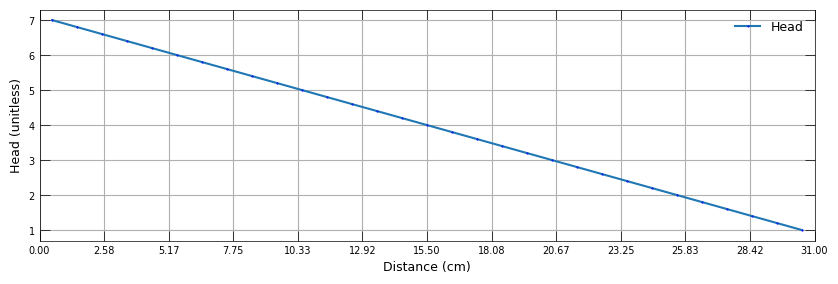

In [22]:
#3a). Resultados del flujo
sim_f, gwf = build_gwf_1D(mesh, tm_par, ph_par, ml_units, os_par, oc_par)
sim_f.write_simulation(silent=True) #Escribe los archivos de entrada necesarios para ejecutar la simulación.
sim_f.run_simulation(silent=True) #Ejecuta la simulación, sin mensajes en la consola durante la ejecución.
xmf6.plot_flow_1D(gwf, mesh, os_par, oc_par) #llama a la función **plot_flow_1D** para visualizar los resultados de la simulación de flujo

## Impresión de propiedades del objeto de simulación sim_f y del modelo de flujo gwf

In [24]:
# Imprimir propiedades del objeto de simulación sim_f
print("Propiedades de sim_f: (Objeto de la simulación)")
print("Nombre de la simulación:", sim_f.name)
print("Directorio de trabajo:", sim_f.simulation_data.mfpath.get_sim_path())

# Imprimir propiedades del modelo de flujo gwf
print("Propiedades de gwf: (Objeto del modelo de flujo)")
print("Nombre del modelo:", gwf.name)
print("Número de paquetes:", len(gwf.package_dict))
print("Paquetes activos:", gwf.package_dict.keys())

Propiedades de sim_f: (Objeto de la simulación)
Nombre de la simulación: flow
Directorio de trabajo: C:\Users\NRBRT\clone\WMACC\notebooks\2_Transporte_mf6_1D/output
Propiedades de gwf: (Objeto del modelo de flujo)
Nombre del modelo: flow
Número de paquetes: 6
Paquetes activos: dict_keys(['dis', 'ic', 'npf', 'chd_0', 'wel-1', 'oc'])


## 3b). Extracción de datos de salida de MODFLOW: lectura de cargas hidráulicas del archivo .hds, balance de flujo del .bud, y calcula velocidades de flujo, procesando resultados de la simulación.

In [26]:
# Obtenemos los resultados de la carga hidráulica
# Lectura de los resultados de la carga hidráulica (niveles de agua) desde el archivo de salida generado por la simulación.
head = flopy.utils.HeadFile( #Construye la ruta completa al archivo de cargas hidráulicas.
    os.path.join(os_par['ws'], #Es la ruta del directorio de salida.
                 oc_par['head_file'])).get_data() #es el nombre del archivo de cargas hidráulicas (por ejemplo, flow.hds).
# Obtenemos los resultados del BUDGET
# Lee los resultados del balance de flujo (flujo de agua) desde el archivo de salida generado por la simulación.
bud  = flopy.utils.CellBudgetFile( 
    os.path.join(os_par['ws'], #Construye la ruta completa al archivo de balance de flujo.
                 oc_par['fbudget_file']), #es el nombre del archivo de balance de flujo (por ejemplo, flow.bud).
    precision='double'
)
# Obtenemos las velocidades
# Extrae y calcula las velocidades (flujos específicos) a partir de los datos del balance de flujo.
spdis = bud.get_data(text='DATA-SPDIS')[0] #Extrae los datos de flujo específico (SPDIS) del archivo de balance de flujo.
# text='DATA-SPDIS': Filtra los datos para obtener solo los flujos específicos.
# **flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)**: Calcula las componentes del flujo específico (qx, qy, qz) 
# a partir de los datos de flujo y el modelo de flujo de agua subterránea (gwf).
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)

## 3c) Impresión de la carga hidráulica y la descarga específica en GWF

In [28]:
# Imprimimos carga hidráulica y descarga específica
print(head.shape, '\n', head)
print(qx.shape, '\n', qx)

(1, 1, 31) 
 [[[7.  6.8 6.6 6.4 6.2 6.  5.8 5.6 5.4 5.2 5.  4.8 4.6 4.4 4.2 4.  3.8
   3.6 3.4 3.2 3.  2.8 2.6 2.4 2.2 2.  1.8 1.6 1.4 1.2 1. ]]]
(1, 1, 31) 
 [[[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
   0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]]]


#========================================================
# INICIA MODELO DE TRANSPORTE
#========================================================

## Paso 4. Simulation object
## Utilizando la biblioteca FloPy, se crea y configura un objeto MFSimulation (sim_t) para realizar la simulación de transporte de solutos en MODFLOW 6, estableciendo el nombre, el directorio de trabajo y su ejecutable.


In [31]:
sim_t = flopy.mf6.MFSimulation(
    sim_name=os_par["tran_name"], 
    sim_ws=os_par["ws"], 
    exe_name=os_par["mf6_exe"]
)
print(sim_t)

sim_name = transport
sim_path = C:\Users\NRBRT\clone\WMACC\notebooks\2_Transporte_mf6_1D/output
exe_name = mf6.exe

###################
Package mfsim.nam
###################

package_name = mfsim.nam
filename = mfsim.nam
package_type = nam
model_or_simulation_package = simulation
simulation_name = transport





## Paso 5. Time discretization object
## Discretización temporal utilizando FloPy. Se define el número de periodos de tiempo, la duración de cada periodo, el número de pasos de tiempo y el factor multiplicador del tamaño del paso.


In [33]:
flopy.mf6.ModflowTdis(
    sim_t, #Objeto de simulación (MFSimulation) al que se le asocia esta configuración de discretización temporal.
    nper=tm_par["nper"], #Si tm_par["nper"] = 3, entonces la simulación tiene 3 periodos de tiempo.
    perioddata=((tm_par["total_time"], #Duración total del periodo.
                 tm_par["nstp"],       #Número de pasos de tiempo en el periodo.
                 tm_par["tsmult"]),),  #Factor de multiplicación del tamaño del paso de tiempo
    time_units=ml_units["time"]
)


package_name = transport.tdis
filename = transport.tdis
package_type = tdis
model_or_simulation_package = simulation
simulation_name = transport

Block options
--------------------
time_units
{internal}
('days')


Block dimensions
--------------------
nper
{internal}
(1)


Block perioddata
--------------------
perioddata
{internal}
(rec.array([(90., 90, 1.)],
          dtype=[('perlen', '<f8'), ('nstp', '<i4'), ('tsmult', '<f8')]))



## Paso 6. IMS object (solution calculation)
## Se configura el Solver (IMS) para MODFLOW 6 utilizando FloPy, especificando el método "bicgstab" para la aceleración lineal en la resolución de ecuaciones


In [35]:
ims = flopy.mf6.ModflowIms(
    sim_t, 
    linear_acceleration="bicgstab"
)
print(ims)

package_name = ims_-1
filename = transport.ims
package_type = ims
model_or_simulation_package = simulation
simulation_name = transport

Block linear
--------------------
linear_acceleration
{internal}
(bicgstab)





## Paso 7. GWT model object (transport)
## Se crea y configura un modelo de transporte de agua subterránea (GWT) en MODFLOW 6 usando FloPy, habilitando el guardado de flujos.

* <font color='Green'> Langevin, C.D., Provost, A.M., Panday, Sorab, and Hughes, J.D., 2022, Documentation for the MODFLOW 6 Groundwater Transport Model: U.S. Geological Survey Techniques and Methods, book 6, chap. A61, 56 p., https://doi.org/10.3133/tm6A61.  

In [38]:
gwt = flopy.mf6.ModflowGwt(
    sim_t, 
    modelname=os_par["tran_name"], 
    save_flows=True
)
print(gwt)

name = transport
model_type = gwt6
version = mf6
model_relative_path = .




## Paso 8. Space discretization object
## Se configura la discretización espacial del modelo de transporte (GWT) en MODFLOW 6 usando FloPy. Define las unidades de longitud, las dimensiones de la malla (número de capas, filas y columnas), el tamaño de las celdas y las elevaciones superior e inferior del modelo

In [40]:
dis = flopy.mf6.ModflowGwtdis(
    gwt,
    length_units=ml_units["length"],
    nlay=mesh.nlay,
    nrow=mesh.nrow,
    ncol=mesh.ncol,
    delr=mesh.delr,
    delc=mesh.delc,
    top=mesh.top,
    botm=mesh.bottom,
)
print("length_units =", ml_units["length"])
print("nlay =", mesh.nlay)
print("nrow =", mesh.nrow)
print("ncol =", mesh.ncol)
print("delr =", mesh.delr)
print("delc =", mesh.delc)
print("top =", mesh.top)
print("botm =", mesh.bottom)
print(dis)

length_units = meters
nlay = 1
nrow = 1
ncol = 31
delr = 1.0
delc = 1.0
top = 1.0
botm = 0.0
package_name = dis
filename = transport.dis
package_type = dis
model_or_simulation_package = model
model_name = transport

Block options
--------------------
length_units
{internal}
(meters)


Block dimensions
--------------------
nlay
{internal}
(1)

nrow
{internal}
(1)

ncol
{internal}
(31)


Block griddata
--------------------
delr
{constant 1.0}

delc
{constant 1.0}

top
{constant 1.0}

botm
{constant 0.0}





## Paso 9. Initial conditions object
## Initial Conditions (IC) Package
## Se configuran las condiciones iniciales de concentración del modelo de transporte en MODFLOW 6. Establece una concentración inicial de 200.0 en una celda específica, y luego se asigna este array como las condiciones iniciales al modelo GWT usando FloPy

In [42]:
# Definimos arreglo temp=np.zeros(nlay,nrow,ncol),dtype=float) para establecer initial_concentration 
nrow = 1    # Number of rows
ncol = 31  # Number of columns
nlay = 1    # Number of layers

init_cond = np.ones((nlay,nrow,ncol),dtype=float)
init_cond = init_cond*3.294e-5
init_cond[:,0,11]=1.647e-7

ic = flopy.mf6.ModflowGwtic(
    gwt, #Objeto del modelo de transporte (ModflowGwt) al que se asociará este paquete.
    strt=init_cond
)
print(ic)

package_name = ic
filename = transport.ic
package_type = ic
model_or_simulation_package = model
model_name = transport

Block griddata
--------------------
strt
{internal}
([[[3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 1.647e-07 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05 3.294e-05
   3.294e-05 3.294e-05 3.294e-05]]])





## Paso 10. Mobile Storage and Transfer (MST) Package
## Se configuran las propiedades del medio poroso y los procesos de transporte para un modelo GWT en MODFLOW 6 usando FloPy
 

In [44]:
mst = flopy.mf6.ModflowGwtmst(
    gwt, #modelo de transporte de MODFLOW 6 en el que se aplica este paquete.
    porosity=ph_par["porosity"], #Especifica la porosidad del medio poroso, obtenida del diccionario de parámetros físicos ph_par.
    **get_sorption_dict(ph_par["retardation_factor"]), #devuelve un diccionario con los parámetros necesarios para modelar adsorción y desorción 
    **get_decay_dict(ph_par["decay_rate"], #especifica la tasa de decaimiento del contaminante.
                     ph_par["retardation_factor"] > 1.0), #condición booleana, indica si el decaimiento ocurre en la fase acuosa (False) o en la fase adsorbida (True).
)

print(mst)

package_name = mst
filename = transport.mst
package_type = mst
model_or_simulation_package = model
model_name = transport

Block griddata
--------------------
porosity
{constant 0.5}





## Paso 11. Advection (ADV) Package
## Se configura el esquema de advección para el modelo de transporte (GWT) en MODFLOW 6 usando FloPy


In [46]:
adv = flopy.mf6.ModflowGwtadv(
    gwt, 
    scheme="TVD"
)
print(adv)

package_name = adv
filename = transport.adv
package_type = adv
model_or_simulation_package = model
model_name = transport

Block options
--------------------
scheme
{internal}
(tvd)





## Paso 12. Dispersion (DSP) Package
## Se Configura la dispersión para el modelo de transporte (GWT) en MODFLOW 6 usando FloPy.

In [48]:
dsp = flopy.mf6.ModflowGwtdsp(
    gwt,
    xt3d_off=True,
    alh=ph_par["longitudinal_dispersivity"],
    ath1=ph_par["longitudinal_dispersivity"],
)

print(dsp)

package_name = dsp
filename = transport.dsp
package_type = dsp
model_or_simulation_package = model
model_name = transport

Block options
--------------------
xt3d_off
{internal}
(True)


Block griddata
--------------------
alh
{constant 0.2}

ath1
{constant 0.2}





## Paso 13. Se establece la conexión entre los resultados del modelo de flujo (GWF) y el modelo de transporte (GWT) en MODFLOW 6. Asocia archivos de salida de carga hidráulica y balance de flujo del GWF con el GWT, permitiendo que el modelo de transporte utilice la información del flujo de agua subterránea para simular el transporte de solutos.


In [50]:
pd = [ 
    ("GWFHEAD", oc_par["head_file"], None),
    ("GWFBUDGET", oc_par["fbudget_file"], None),
]
    
fmi = flopy.mf6.ModflowGwtfmi(
    gwt, 
    packagedata=pd
)
print(fmi)

package_name = fmi
filename = transport.fmi
package_type = fmi
model_or_simulation_package = model
model_name = transport

Block packagedata
--------------------
packagedata
{internal}
([('GWFHEAD', 'flow.hds') ('GWFBUDGET', 'flow.bud')])





## Paso 14. Configura las fuentes de soluto para el modelo de transporte (GWT) en MODFLOW 6 usando FloPy. Especifica que la fuente "WEL-1" (pozo) tiene una columna auxiliar "CONCENTRATION" que define la concentración del soluto inyectado.


In [52]:
sourcerecarray = [["WEL-1", "AUX", "CONCENTRATION"]]
ssm = flopy.mf6.ModflowGwtssm(
    gwt, 
    sources=sourcerecarray
)
print(ssm)

package_name = ssm
filename = transport.ssm
package_type = ssm
model_or_simulation_package = model
model_name = transport

Block sources
--------------------
sources
{internal}
([('WEL-1', 'AUX', 'CONCENTRATION')])





## Paso 15. Observation locations
## Se define un diccionario obs_data que especifica puntos de observación para la simulación de transporte. Asocia un archivo CSV ("transporte.obs.csv") con una lista de puntos de observación,


In [54]:
obs_data = {
    "transporte.obs.csv": [
        ("X005", "CONCENTRATION", (0, 0, 0)),
        ("X011", "CONCENTRATION", (0, 0, 11)),
        ("X030", "CONCENTRATION", (0, 0, 30)),
    ],
}

obs_package = flopy.mf6.ModflowUtlobs(
    gwt, 
    digits=10, 
    print_input=True, 
    continuous=obs_data
)

print(obs_package)

package_name = obs_0
filename = transport.obs
package_type = obs
model_or_simulation_package = model
model_name = transport

Block options
--------------------
digits
{internal}
(10)

print_input
{internal}
(True)


Block continuous
--------------------
continuous
{internal}
([('X005', 'CONCENTRATION', (0, 0, 0), None)
 ('X011', 'CONCENTRATION', (0, 0, 11), None)
 ('X030', 'CONCENTRATION', (0, 0, 30), None)])





## Paso 16. Output object
## Se configuran las opciones de salida (OC) para el modelo de transporte (GWT) en MODFLOW 6 usando FloPy.

In [56]:
oc = flopy.mf6.ModflowGwtoc(
    gwt,
    budget_filerecord=oc_par["tbudget_file"],
    concentration_filerecord=oc_par["concentration_file"],
    saverecord=[("CONCENTRATION", "ALL"), ("BUDGET", "LAST")],
    printrecord=[("CONCENTRATION", "LAST"), ("BUDGET", "LAST")],
)

print(oc)

package_name = oc
filename = transport.oc
package_type = oc
model_or_simulation_package = model
model_name = transport

Block options
--------------------
budget_filerecord
{internal}
([('transport.bud',)])

concentration_filerecord
{internal}
([('transport.ucn',)])


Block period
--------------------
saverecord
{internal}
([('CONCENTRATION', 'ALL', None) ('BUDGET', 'LAST', None)])

printrecord
{internal}
([('CONCENTRATION', 'LAST', None) ('BUDGET', 'LAST', None)])





## Paso 17. Write Input files.
##  Se le indica a FloPy para que escriba todos los archivos de entrada necesarios para ejecutar la simulación de transporte de solutos en MODFLOW 6.


In [58]:
sim_t.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing ims package ims_-1...
  writing model transport...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package mst...
    writing package adv...
    writing package dsp...
    writing package fmi...
    writing package ssm...
    writing package obs_0...
    writing package oc...


## Paso 18. Run simulation
## Se ejecuta la simulación de transporte de solutos previamente configurada en MODFLOW 6 utilizando Flopy. 


In [60]:
sim_t.run_simulation()

FloPy is using the following executable to run the model: C:\Users\nrbrtvr\GEOFISICA\PROYECTOS\MT3D\DESCARGAS-MF-MT3D\mf6.4.2\mf6.4.2_win64\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.4.2 06/28/2023

   MODFLOW 6 compiled Jun 28 2023 18:41:13 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software i

(True, [])

## Paso 19. Postprocessing
##  Devuelve una lista con los nombres de los modelos que componen la simulación.
### Resultados del transporte

In [62]:
# listar los nombres de los modelos incluidos en una simulación de MODFLOW 6.
sim_t.model_names

dict_keys(['transport'])

### En **mf6gwt_ra = sim_t.get_model("transport").obs.output.obs().data**
* ## mf6gwt_ra: Se obtienen los datos de observación de la simulación de transporte.
### En **ucnobj_mf6 = sim_t.transport.output.concentration()**
* ## ucnobj_mf6: Se extraen los datos de concentración de solutos del modelo de transporte.

In [64]:
mf6gwt_ra = sim_t.get_model("transport").obs.output.obs().data
ucnobj_mf6 = sim_t.transport.output.concentration()

In [65]:
print(type(mf6gwt_ra), type(ucnobj_mf6))

<class 'numpy.recarray'> <class 'flopy.utils.binaryfile.HeadFile'>


In [66]:
print(mf6gwt_ra.shape)
#print(mf6gwt_ra) #(tiempo, C0, C40 y C110)

(90,)


## Se extraen los tiempos de simulación para los datos de observación mf6gwt_ra

In [68]:
simtimes = mf6gwt_ra["totim"]
simtimes.shape
print(type(simtimes), simtimes)


<class 'numpy.ndarray'> [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.
 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90.]


In [69]:
obsnames = ["X005", "X011", "X030"]

## Se visualización las cargas utilizando "flow.hds"


Tiempos disponibles: 0: 1.00, 1: 2.00, 2: 3.00, 3: 4.00, 4: 5.00, 5: 6.00, 6: 7.00, 7: 8.00, 8: 9.00, 9: 10.00, 10: 11.00, 11: 12.00, 12: 13.00, 13: 14.00, 14: 15.00, 15: 16.00, 16: 17.00, 17: 18.00, 18: 19.00, 19: 20.00, 20: 21.00, 21: 22.00, 22: 23.00, 23: 24.00, 24: 25.00, 25: 26.00, 26: 27.00, 27: 28.00, 28: 29.00, 29: 30.00, 30: 31.00, 31: 32.00, 32: 33.00, 33: 34.00, 34: 35.00, 35: 36.00, 36: 37.00, 37: 38.00, 38: 39.00, 39: 40.00, 40: 41.00, 41: 42.00, 42: 43.00, 43: 44.00, 44: 45.00, 45: 46.00, 46: 47.00, 47: 48.00, 48: 49.00, 49: 50.00, 50: 51.00, 51: 52.00, 52: 53.00, 53: 54.00, 54: 55.00, 55: 56.00, 56: 57.00, 57: 58.00, 58: 59.00, 59: 60.00, 60: 61.00, 61: 62.00, 62: 63.00, 63: 64.00, 64: 65.00, 65: 66.00, 66: 67.00, 67: 68.00, 68: 69.00, 69: 70.00, 70: 71.00, 71: 72.00, 72: 73.00, 73: 74.00, 74: 75.00, 75: 76.00, 76: 77.00, 77: 78.00, 78: 79.00, 79: 80.00, 80: 81.00, 81: 82.00, 82: 83.00, 83: 84.00, 84: 85.00, 85: 86.00, 86: 87.00, 87: 88.00, 88: 89.00, 89: 90.00


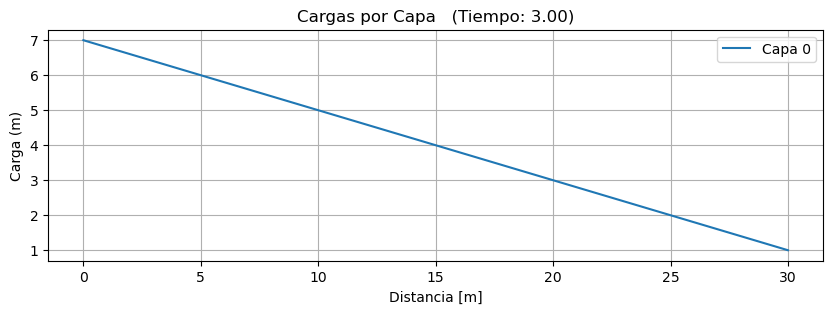

In [71]:
from flopy.utils import HeadFile
from flopy.utils import UcnFile
import matplotlib.pyplot as plt
import numpy as np  # Importación necesaria para cálculos numéricos

def plot_head_lines(file_path, stress_period_index=-1):
    # Cargar archivo de cargas
    head_file = HeadFile(file_path)
    
    # Obtener todos los tiempos disponibles
    times = head_file.get_times()
    
    # Mostrar los períodos de estrés disponibles en una sola línea
    stress_periods_str = ", ".join([f"{i}: {t:.2f}" for i, t in enumerate(times)])
    print(f"\nTiempos disponibles: {stress_periods_str}")
    
    # Asegurar que el índice está dentro de los límites
    if stress_period_index < 0:
        stress_period_index = len(times) + stress_period_index  # Permite usar -1 para el último, -2 para el penúltimo, etc.
    
    if stress_period_index >= len(times):
        raise ValueError(f"El índice de período de estrés {stress_period_index} está fuera de rango. Hay {len(times)} disponibles.")
    
    # Obtener los datos de carga para el período seleccionado
    head_data = head_file.get_data(totim=times[stress_period_index])
    
    num_layers = head_data.shape[0]
    num_cols = head_data.shape[2]
    x = np.arange(num_cols)  # Eje X representando las columnas
    
    # Configuración de la figura
    fig, ax = plt.subplots(figsize=(10, 3))
    
    for i in range(num_layers):
        layer_data = np.nanmean(head_data[i], axis=0)  # Promedio por columna
        ax.plot(x, layer_data, label=f"Capa {i}")
    
    # Configuración de la gráfica
    ax.set_xlabel("Distancia [m]")
    ax.set_ylabel("Carga (m)")
    ax.set_title(f"Cargas por Capa   (Tiempo: {times[stress_period_index]:.2f})")
    ax.legend()
    ax.grid()
    
    plt.show()

# Uso del script para visualizar todas las capas de carga con líneas para un período de estrés específico
plot_head_lines("./output/flow.hds", stress_period_index=2)  # Cambia el índice según el periodo deseado


## Se visualiza el campo de concentraciones para t=t1, y t=t2, utilizando ucnobj_mf6

Tiempos disponibles:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0]
Campo de concentraciones para t =  10.0 dias
[3.29400000e-05 3.29400000e-05 3.29400000e-05 3.29399999e-05
 3.29399994e-05 3.29399946e-05 3.29399502e-05 3.29395719e-05
 3.29365998e-05 3.29155497e-05 3.27856134e-05 3.21287089e-05
 2.99878823e-05 2.73707510e-05 2.65624757e-05 2.68967933e-05
 2.83994528e-05 3.00725208e-05 3.12902074e-05 3.20483832e-05
 3.24805984e-05 3.27121955e-05 3.28305647e-05 3.28888203e-05
 3.29166113e-05 3.29295248e-05 3.293

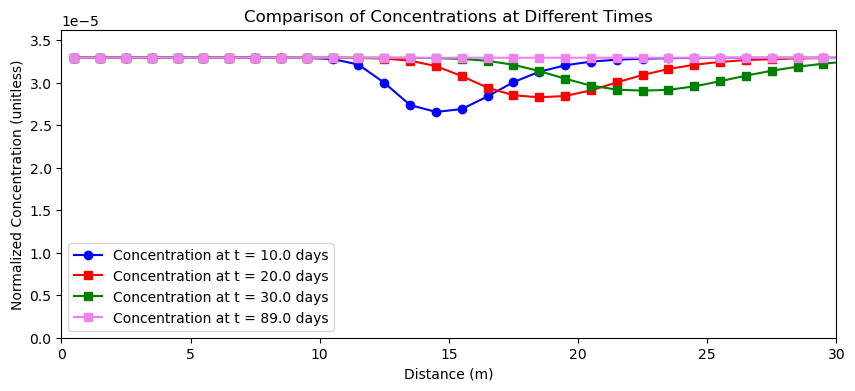

In [73]:
# Visualización de la concentración en dos tiempos diferentes: (t1,t2)
import matplotlib.pyplot as plt

# Define los dos tiempos de interés
t1 = 10.0
t2 = 20.0
t3 = 30.0
t4 = 89.0

print('Tiempos disponibles:')
print(ucnobj_mf6.get_times())

# Obtén los datos de concentración simulados para cada tiempo
simconc_t1 = ucnobj_mf6.get_data(totim=t1).flatten()
simconc_t2 = ucnobj_mf6.get_data(totim=t2).flatten()
simconc_t3 = ucnobj_mf6.get_data(totim=t3).flatten()
simconc_t4 = ucnobj_mf6.get_data(totim=t4).flatten()

# Obtén las coordenadas (por ejemplo, x)
x, _, _ = mesh.get_coords()

print('Campo de concentraciones para t = ',t1,'dias')
print(simconc_t1) #Impresión numérica de datos de concentración
print('Campo de concentraciones para t = ',t2,'dias')
print(simconc_t2) #Impresión numérica de datos de concentración
print('Campo de concentraciones para t = ',t3,'dias')
print(simconc_t3) #Impresión numérica de datos de concentración
print('Campo de concentraciones para t = ',t4,'dias')
print(simconc_t4) #Impresión numérica de datos de concentración
# Crear la gráfica en formato de líneas para ambos tiempos
plt.figure(figsize=(10, 4))
plt.plot(x, simconc_t1, marker="o", linestyle="-", color="blue", label=f"Concentration at t = {t1} days")
plt.plot(x, simconc_t2, marker="s", linestyle="-", color="red",  label=f"Concentration at t = {t2} days")
plt.plot(x, simconc_t3, marker="s", linestyle="-", color="green",  label=f"Concentration at t = {t3} days")
plt.plot(x, simconc_t4, marker="s", linestyle="-", color="violet",  label=f"Concentration at t = {t4} days")
plt.xlabel("Distance (m)")
plt.ylabel("Normalized Concentration (unitless)")
plt.title("Comparison of Concentrations at Different Times")
plt.xlim(0, 30)

# Ajusta el límite superior del eje Y basado en el valor máximo de ambos conjuntos de datos
max_y = max(simconc_t1.max(), simconc_t2.max(), simconc_t3.max(), simconc_t4.max())
plt.ylim(0, max_y * 1.1)

plt.legend()
plt.show()